<a href="https://colab.research.google.com/github/mdkamrulhasan/machine_learning_concepts/blob/master/notebooks/supervised/image_classification_10c_cnn_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training an image classifier
We will do the following steps in order:



1.   Load and normalize the training and test datasets
2.   Define a Convolutional Neural Network
3.   Define a loss function
4.   Train the network on the training data
5.   Test the network on the training data
6.   Making predictions for the test data

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
import os
import pickle

## 1. Load data

In [ ]:
drive.mount('/content/drive')

# 'Your Google Drive Path where you uploaded train_X_y.pkl and test_X.pkl'
base_path = 'drive/MyDrive/data/kaggle-challenges/W2026-0-0.3'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Training data
with open(os.path.join(base_path, 'train_X_y.pkl'),'rb') as f:
    X_train, y_train = pickle.load(f)

# Test data
with open(os.path.join(base_path, 'test_X.pkl'),'rb') as f:
    X_test = pickle.load(f)

In [ ]:
# Reshaping data matrices
X_train = np.transpose(X_train.astype(int), (0, 3, 1, 2))
X_test= np.transpose(X_test.astype(int), (0, 3, 1, 2))
X_train.shape

(42000, 3, 16, 16)

In [ ]:
# 1. Define a custom Data Loader
class NumpyDataset(Dataset):
    def __init__(self, X, Y=None, transform=None):
        self.X = torch.from_numpy(X).float()  # convert to float tensor
        if Y is not None:
          self.Y = torch.from_numpy(Y).long()   # convert to long tensor
        else:
          self.Y = torch.from_numpy(np.zeros(len(self.X))).long()
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]

        if self.transform:
            x = self.transform(x)
        return x, y



In [ ]:
# Data Loaders + Batch Size
transform = transforms.Compose(
    [transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 64 #10


train_dataset = NumpyDataset(X_train, y_train.flatten(), transform=transform)
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = NumpyDataset(X_test, transform=transform)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

### Display some images

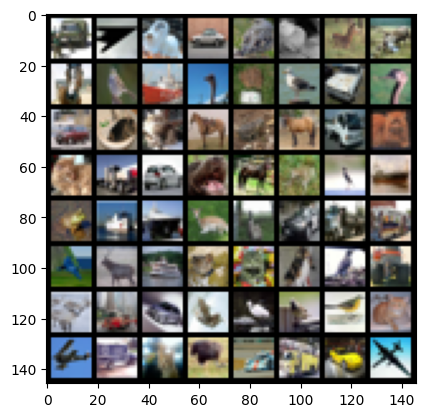

In [ ]:

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy().astype(int)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Load some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)
# Show images
imshow(torchvision.utils.make_grid(images))


##2. Define a CNN model architecture

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class SimpleCNN_Level1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        self.fc1 = nn.Linear(16 * 1 * 1, 120)
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x



class SimpleCNN_Level2(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected layers
        self.fc1 = nn.Linear(64, 128)

        # ✅ Layer Normalization (applied after fc1)
        self.ln1 = nn.LayerNorm(128)

        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Conv block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Conv block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Adaptive pooling
        x = self.adaptive_pool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Fully connected + LayerNorm
        x = self.fc1(x)
        x = self.ln1(x)   # ✅ Apply LayerNorm here
        x = F.relu(x)

        # Dropout
        x = self.dropout(x)

        # Output layer
        x = self.fc2(x)
        return x


# CNN model instantiation
# net = SimpleCNN_Level1()
net = SimpleCNN_Level2()

In [ ]:
# from torchsummary import summary
# summary(net, input_size=(3, 16, 16))

##3. Define a Loss function

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(net.parameters(), lr=0.0001, momentum=0.9)
optimizer = optim.Adam(net.parameters(),
                       lr=0.0001, betas=(0.9, 0.999),
                       eps=1e-08, weight_decay=0.01)

##4. Model/network training

In [ ]:
NB_EPOCHS = 100

for epoch in range(NB_EPOCHS):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # Get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

Finished Training


## 5. Test the network on the training data

In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
output_labels = []
with torch.no_grad():
    for data in trainloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        output_labels += predicted.tolist()
        # total += labels.size(0)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Training accuracy of the network: {100 * correct // total} %')

##6. Test the network on test data

In [ ]:
correct, len(output_labels), total

(20820, 42000, 42000)

In [ ]:
correct, len(output_labels), total

(20162, 42000, 42000)

In [ ]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
output_labels = []
with torch.no_grad():
    for data in testloader:
        images, _ = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        output_labels += predicted.tolist()
        total += labels.size(0)

##7. Export Test data predictions for Kaggle Challenge Input

In [ ]:
# Pack results in a pandas dataframe
import pandas as pd
test_predictions = pd.DataFrame({
    'rowId': range(0, len(output_labels)),
    'label': output_labels})

In [ ]:
test_predictions.head()

,rowId,label
0,0,6
1,1,2
2,2,0
3,3,1
4,4,4


In [ ]:
# Exporting resluts
test_predictions.to_csv(os.path.join(base_path, 'my_cnn_results.csv'), index=False)

### Save/Persist the model for future reference

In [ ]:
PATH = './my_cnn_model.pth'
torch.save(net.state_dict(), PATH)

### How to load the model?

In [ ]:
net = SimpleCNN()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>